In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

from numba import jit
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
@jit(nopython=True)
def autocorrelation(System, SystemSnapshot):
    Ly, Lx = System.shape
    Ly0,Lx0 = SystemSnapshot.shape
    
    if Ly0 != Ly or Lx0 != Lx:
        raise ValueError("Shape of System and SystemSnapshot is not equal")
    
    size = Lx * Ly    
    DensityParticles = np.sum(System) / size
    
    Sum = 0
    for i in range(Ly):
        for j in range(Lx):
            Sum += System[i][j] * SystemSnapshot[i][j]
    Corr = (Sum / size) - (DensityParticles)**2 # 0.25 is the density of particles^2
    
    return Corr

        
def checkboard(mu, sigma): # Filling the lattice (Lx*Ly) with particles alternatively (chess fashion)    
    System = np.zeros((Ly, Lx), dtype=int)  # Ly vectors with Lx (zero) components 

    System[::2, ::2] = 1  # Set even rows and even columns to 1
    System[1::2, 1::2] = 1  # Set odd rows and odd columns to 1

    JumpRateGrid = np.ones((Ly,Lx))*(-0.1)
    for i in range(Ly):
        for j in range(Lx):
            if System[i][j] == 1:
                JumpRateGrid[i][j] = np.random.normal(mu, sigma) # probability of jumping forward or transversally
                
                # Limiting its values to [0,1]
                if JumpRateGrid[i][j] > 1:
                    JumpRateGrid[i][j] = 1
                elif JumpRateGrid[i][j] < 0:
                    JumpRateGrid[i][j] = 0
                    
    return System, JumpRateGrid

def random_system(n, mu, sigma): # Filling the lattice (Lx*Ly) randomly with n particles
    System = np.concatenate((np.ones(n, int), np.zeros(Lx*Ly-n, int))) #CHECK DIMENSIONs
    np.random.shuffle(System)
    System = System.reshape((Ly, Lx))
    
    JumpRateGrid = np.ones((Ly,Lx))*(-0.1)
    for i in range(Ly):
        for j in range(Lx):
            if System[i][j] == 1:
                JumpRateGrid[i][j] = np.random.normal(mu, sigma) # probability of jumping forward or transversally
                
                # Limiting its values to [0,1]
                if JumpRateGrid[i][j] > 1:
                    JumpRateGrid[i][j] = 1
                elif JumpRateGrid[i][j] < 0:
                    JumpRateGrid[i][j] = 0

    return System, JumpRateGrid  

def select_action(System, X, Y, Along_count, Transv_count, print_stuff): # Action over the (X,Y) lattice site

    # TASEP with p=1/2 of jumping foward, p=1/4 of jumping up or down, in total p=1/2
    dice_jump = random.randint(0, 1) 
    if dice_jump == 0:
        JumpAlong = 0
        JumpTransverse = 2 # No jump up or down
    else:
        JumpAlong = 2 # No jump forward
        JumpTransverse = random.randint(0, 1)

    # Update System to the movement 
    System, Along_count, Transv_count = update_System(System, X, Y, Along_count, Transv_count, JumpAlong, JumpTransverse, print_stuff)

    return System, Along_count, Transv_count


In [3]:
# Simulation parameters
runsNumber = 5
totalMCS = 200 #Total number of Monte Carlo steps per single run
Lx = 40 # Number of columns, length
Ly = 20 # Number of rows, height
init = "chess"
mu = 0.5
sigma = 0.5

N = Lx * Ly // 2 # Number of particles
size = Lx * Ly

# Check utilities
print_stuff = 1 #0 do not print; 1 print basics; 2 print details; for unit tests
if print_stuff == 2 and totalMCS > 10:
    raise ValueError("totalMCS too big to print everything")
SystemCheckboard = np.zeros((Ly, Lx), dtype=int)  # Ly vectors with Lx (zero) components 
SystemCheckboard[::2, ::2] = 1  # Set even rows and even columns to 1
SystemCheckboard[1::2, 1::2] = 1  # Set odd rows and odd columns to 1

# Memory allocation                   
DensityParticlesTot = np.zeros(totalMCS) 
CorrTot = np.zeros(totalMCS) 
CurrentAlongTot = np.zeros(totalMCS)  # totalMCS vectors with Ly (zero) components 
CurrentTransvTot = np.zeros(totalMCS)  # totalMCS vectors with Ly (zero) components
OccupationGridTot = np.zeros((Ly, Lx))

#Beginning of the simulation
for iwalk in range(runsNumber):
    # Initial Conditions
    if init == "chess":  # Filling the lattice with particles alternatively (chess fashion)
        System, JumpRateGrid = checkboard(mu, sigma)
    elif init == "random": # Filling the lattice with N particles randomly
        System, JumpRateGrid = random_system(N, mu, sigma)
    
    # Mapping System at t=0
    SystemSnapshot = System.copy()

    if init == "chess" and print_stuff > 0: 
        if (SystemSnapshot != SystemCheckboard).all(): raise ValueError("System at t=0, not in checkboard mode")

    # Frames for the animation
     # Frames of the location of particles
    System_movie = np.zeros((N+1, Ly, Lx), dtype=int)
    System_movie[0] = SystemSnapshot
    
     # Frames of each movement in one MCS
    JumpRate_movie = np.zeros(((totalMCS*N)+1, Ly, Lx))
    JumpRate_movie[0] = JumpRateGrid
    
     # Frames of set of movements after one MCS   
    JumpRate_short_movie = np.zeros((totalMCS+1, Ly, Lx))
    JumpRate_short_movie[0] = JumpRateGrid 
    
    # Memory allocation                   
    Corr = np.zeros(totalMCS)
    DensityParticles = np.zeros(totalMCS) 
    OccupationGrid = np.zeros((Ly, Lx))
    CurrentAlong = np.zeros(totalMCS) 
    CurrentTransv = np.zeros(totalMCS)

    # Beginning of a single run
    for istep in range(totalMCS):
        if print_stuff == 2: print("MonteCarlo iteration:", istep)
        
        Along_count = 0
        Transv_count = 0

        # Computes correlation function; CorrFunction[0] = 0.25 by definition 
        Corr[istep] += autocorrelation(System, SystemSnapshot)
        if init == "chess" and Corr[0] != 0.25:
            raise ValueError("Initial correlation at the checkboard distribution is not 0.25")
        
        for moveAttempt in range(N): # To make a move over all particles
            while True:
                dice = random.randint(0, Lx * Ly - 1)  # Picks the random lattice site in the array
                X = dice // Lx
                Y = dice - X * Lx

                """ 
                The lattice is labelled from the left top to the right 
                 as Z= 0, 1, 2    or    [X,Y]= (0,0), (0,1), (0,2) 
                       3, 4, 5                 (1,0), (1,1), (1,2)
                """

                if System[X][Y] == 1: # The lattice has to be occupied
                    
                    JumpRate = JumpRateGrid[X][Y] # probability of jumping forward or transversally
                    dice = random.random() 
                    if print_stuff == 2: print("* Particle at (%s, %s) move attempt:"% (X,Y))

                    if dice < JumpRate:
                        JumpAlong = 0 
                        JumpTransverse = 2 # No jump up or down
                        if print_stuff == 2: print("   Tries to jump along: dice = %s < Jumprate = %s:"% (dice, JumpRate))

                    else:
                        JumpAlong = 2 # No jump backwards
                        JumpTransverse = random.randint(0, 1) # 0.5 prob of jumping up or down
                        if print_stuff == 2: print("   Tries to jump transversally: dice = %s > Jumprate = %s"% (dice, JumpRate))
                        
                
                    # Updating the system
                    # Simple implementation of Periodic boundary conditions
                    xPrev = Ly - 1 if X == 0 else X - 1        
                    xNext = 0 if X == Ly - 1 else X + 1
                    yNext = 0 if Y == Lx - 1 else Y + 1
                    

                    if JumpAlong == 0:             # hop forward
                        if System[X][yNext] == 0:  # if next site is free
                            temp = System[X][Y]
                            System[X][Y] = System[X][yNext]
                            System[X][yNext] = temp

                            temp2 = JumpRateGrid[X][Y]
                            JumpRateGrid[X][Y] = JumpRateGrid[X][yNext]
                            JumpRateGrid[X][yNext] = temp2
                        
                            Along_count += 1
                            
                            if print_stuff == 2: print("   Particle at (%s, %s) hops forward" % (X, Y))
                        else:
                            if print_stuff == 2: print("   Particle at (%s, %s) can't jump due an obstacle" % (X, Y))

                    if JumpTransverse == 0: # hop up
                        if System[xPrev][Y] == 0: 
                            temp = System[X][Y]
                            System[X][Y] = System[xPrev][Y]
                            System[xPrev][Y] = temp

                            temp2 = JumpRateGrid[X][Y]
                            JumpRateGrid[X][Y] = JumpRateGrid[xPrev][Y]
                            JumpRateGrid[xPrev][Y] = temp2

                            Transv_count += 1
                            
                            if print_stuff == 2: print("   Particle at (%s, %s) hops up" % (X, Y))
                        else:
                            if print_stuff == 2: print("   Particle at (%s, %s) can't jump due an obstacle" % (X, Y))

                    if JumpTransverse == 1: # hop down
                        if System[xNext][Y] == 0: 
                            temp = System[X][Y]
                            System[X][Y] = System[xNext][Y]
                            System[xNext][Y] = temp

                            temp2 = JumpRateGrid[X][Y]
                            JumpRateGrid[X][Y] = JumpRateGrid[xNext][Y]
                            JumpRateGrid[xNext][Y] = temp2

                            Transv_count -= 1
                            
                            if print_stuff == 2: print("   Particle at (%s, %s) hops down" % (X, Y))
                        else:
                            if print_stuff == 2: print("   Particle at (%s, %s) can't jump due an obstacle" % (X, Y))
                        
                    # Frames for the movie
                    System_movie[moveAttempt+1] = System
                    JumpRate_movie[(istep*N)+moveAttempt+1] = JumpRateGrid

                    break  # Exit the loop
                    
        # Frames for the movie at the last MCS
        JumpRate_short_movie[istep+1] = JumpRateGrid
        
        # Computes currents
        CurrentAlong[istep] = Along_count / N # Sum of the current along Lx
        CurrentTransv[istep] = Transv_count / N # Sum of the current along Ly

        # Computes the total number of particles
        DensityParticles[istep] = np.sum(System) / size
        
        if DensityParticles[istep] != 0.5:
            raise ValueError("The density of particles does not conserve")

        # To compute occupation probability
        OccupationGrid += System


    # Computing parameters after a single run
    OccupationGrid /= totalMCS
    OccupationGridTot += OccupationGrid
    
    for dt in range(totalMCS):
        CorrTot[dt] += Corr[dt]
        DensityParticlesTot[dt] += DensityParticles[dt] 
        CurrentAlongTot[dt] += CurrentAlong[dt]
        CurrentTransvTot[dt] += CurrentTransv[dt]
        
        
    if print_stuff == 1 or print_stuff == 2: print("Runs done:", iwalk+1)


# Simulation results output
for dt in range(totalMCS):
    CorrTot[dt] /= runsNumber
    DensityParticlesTot[dt] /= (runsNumber)
    CurrentAlongTot[dt] /= (runsNumber)
    CurrentTransvTot[dt] /= (runsNumber)

# Occupation probability along the X axis
OccupationGridTot /= runsNumber
HorizontalOccupProb = OccupationGridTot.sum(axis=0)/Ly


print('Finished!')

Runs done: 1
Runs done: 2
Runs done: 3
Runs done: 4
Runs done: 5
Finished!


In [4]:
fig = plt.figure()
ax = fig.add_subplot(111)

#fig.patch.set_facecolor('grey') #Change background color

# To position colorbars 
div = make_axes_locatable(ax)
cax = div.append_axes('right', '5%', '5%')

cv0 = JumpRate_short_movie[0]
im = ax.imshow(cv0, cmap = "gnuplot")
cb = fig.colorbar(im, cax=cax)

#tx1 = fig.annotate('MC 1', xy=(0,-0))
tx2 = ax.set_title('Frame 0', y=1)

axoff = ax.axis('off')

plt.close() # To not have the plot of frame 0 

def animate(frame):
    #arr = System_movie[frame]
    arr = JumpRate_short_movie[frame]
    vmax     = 1
    vmin     = np.min(arr)
    im.set_data(arr)
    im.set_clim(vmin, vmax)
    cb.ax.set_ylabel('Jumping Rate')
    #tx1.set_text('MC 1')
    tx2.set_text('Frame {0}'.format(frame))
    # The colorbar updates itself when the mappable it watches (im) changes
    
#ani = FuncAnimation(fig, animate, frames=len(System_movie), repeat=False)
ani = FuncAnimation(fig, animate, frames=len(JumpRate_short_movie), repeat=False)

HTML(ani.to_jshtml())
# #ani.save('animation_random.mp4')
# #plt.show()

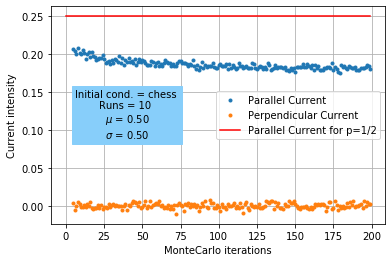

In [10]:
x_axis=np.array(range(totalMCS))

#The steady current of particle J, through a bond i, i+1 is given by the rate r multiplied by the probability that there is a particle at site i, and site i+1 is vacant
r=1
p=1/2
prob_vac=1/2
f2=np.array([r*p*prob_vac]*totalMCS)

plt.plot(x_axis[5:], CurrentAlongTot[5:], '.', label='Parallel Current')
plt.plot(x_axis[5:], CurrentTransvTot[5:], '.', label='Perpendicular Current')

plt.plot(x_axis,f2, label='Parallel Current for p=1/2', color = 'red')

plt.xlabel('MonteCarlo iterations')
plt.ylabel('Current intensity')
plt.legend(loc = 'center right')
stats = ('Initial cond. = %s \n'
             f'Runs = %i \n'
             f'$\\mu$ = {mu:.2f}\n'
             f'$\\sigma$ = {sigma:.2f}'% (init, runsNumber))
plt.text(totalMCS/5, 0.12, stats , fontsize=10, ha="center", va="center",
         bbox=dict(boxstyle="square",color= 'lightskyblue'))

plt.grid(True)

#plt.savefig('Random_sigma=0,01 -  Currents.pdf')

plt.show()

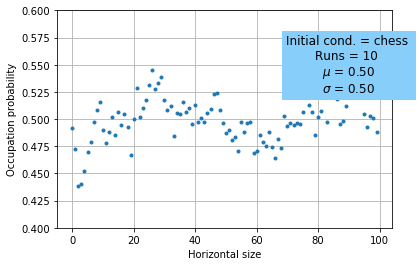

In [11]:
x_axis=np.array(range(Lx))

plt.plot(x_axis, HorizontalOccupProb, '.')

plt.xlabel('Horizontal size')
plt.ylabel('Occupation probability')

stats = ('Initial cond. = %s \n'
             f'Runs = %i \n'
             f'$\\mu$ = {mu:.2f}\n'
             f'$\\sigma$ = {sigma:.2f}'% (init, runsNumber))
plt.text(Lx-10, 0.55, stats , fontsize=12, ha="center", va="center",
         bbox=dict(boxstyle="square",color= 'lightskyblue'))

plt.ylim([0.4,0.6])
plt.grid(True)

#plt.savefig('Random_sigma=0,01 - Occupation probability.pdf')

plt.show()

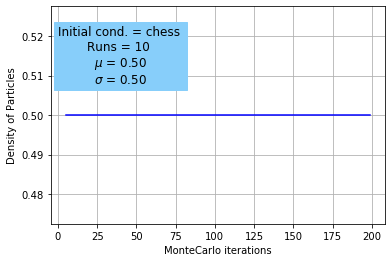

In [8]:
x_axis=np.array(range(totalMCS))
plt.plot(x_axis[5:], DensityParticlesTot[5:], color='blue')
plt.xlabel('MonteCarlo iterations')
plt.ylabel('Density of Particles')
stats = ('Initial cond. = %s \n'
             f'Runs = %i \n'
             f'$\\mu$ = {mu:.2f}\n'
             f'$\\sigma$ = {sigma:.2f}'% (init, runsNumber))

plt.text(totalMCS/5, 0.515, stats , fontsize=12, ha="center", va="center",
         bbox=dict(boxstyle="square",color= 'lightskyblue'
                   ))
plt.grid(True) 
#plt.savefig('Random_sigma=0,3 - Density.pdf')

plt.show()

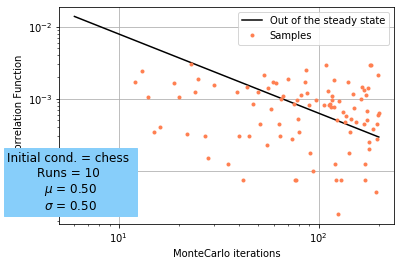

In [9]:
x_axis=np.array(range(1,totalMCS+1))
f=1/x_axis
f2 = 0.1*x_axis**(-1.1)
plt.plot(x_axis[5:], f2[5:], color='black', label = 'Out of the steady state')
plt.plot(x_axis[5:], CorrTot[5:], '.', color='coral', label = 'Samples')
plt.xlabel('MonteCarlo iterations')
plt.ylabel('Autocorrelation Function')
plt.legend()
stats = ('Initial cond. = %s \n'
             f'Runs = %i \n'
             f'$\\mu$ = {mu:.2f}\n'
             f'$\\sigma$ = {sigma:.2f}'% (init, runsNumber))
plt.text(totalMCS/35, 0.00007, stats , fontsize=12, ha="center", va="center",
         bbox=dict(boxstyle="square",color= 'lightskyblue'
                   ))

plt.xscale('log')
plt.yscale('log')
plt.grid(True)

#plt.savefig('Random_sigma=0,01 - Autocorrelation')

plt.show()